In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
file_path = r"C:\Users\USER\Downloads\toxicity dataset.csv"
df_toxicity = pd.read_csv(file_path, encoding='ascii')
print(df_toxicity.head())
print(df_toxicity.columns)

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

(171, 1204)
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64
count    1204.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64


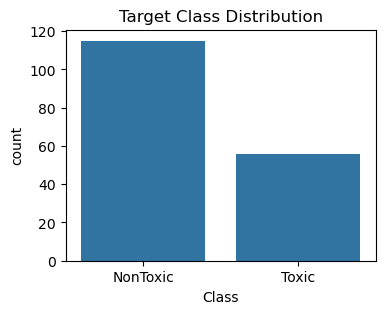

In [2]:
print(df_toxicity.shape)
print(df_toxicity['Class'].value_counts())
missing_ratio = df_toxicity.isna().mean()
print(missing_ratio.describe())
plt.figure(figsize=(4,3))
sns.countplot(x='Class', data=df_toxicity)
plt.title('Target Class Distribution')
plt.show()

In [3]:
print(df_toxicity.dtypes)

MATS3v             float64
nHBint10             int64
MATS3s             float64
MATS3p             float64
nHBDon_Lipinski      int64
                    ...   
nT5Ring              int64
SHdNH              float64
ETA_dEpsilon_C     float64
MDEO-22            float64
Class               object
Length: 1204, dtype: object


In [4]:
print(df_toxicity.duplicated().sum())

0


In [5]:
print(df_toxicity.describe())

           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  ...   
mean     0.677770   -0.025418   -0.053289    1.569251    0.003226  ...   
std      1.647322    0.078645    0.109463    2.497362    0.074076  ...   
min      0.000000   -0.211900   -0.47

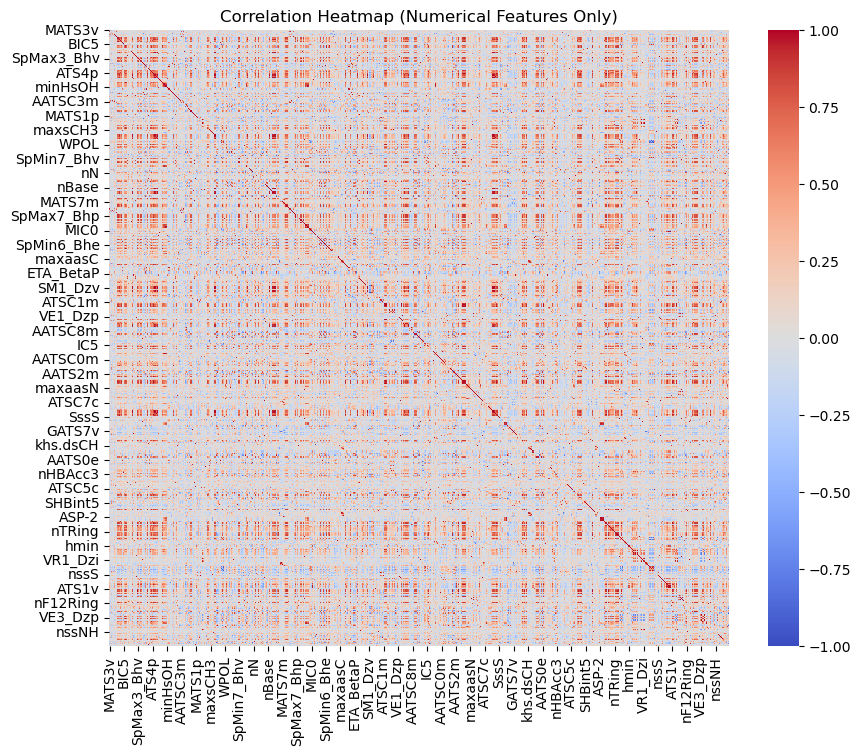

In [6]:
numerical_df = df_toxicity.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

In [7]:
# Separate features and target
X = df_toxicity.drop("Class", axis=1)
y = df_toxicity["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (171, 1203)
Target shape: (171,)


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Encoded classes:", le.classes_)

Encoded classes: ['NonToxic' 'Toxic']


In [9]:
print(pd.Series(y).value_counts())

0    115
1     56
Name: count, dtype: int64


In [10]:
print(X.isna().sum().sort_values(ascending=False).head(10))

MDEO-22     0
MATS3v      0
nHBint10    0
AATSC1c     0
AATSC1m     0
AATSC1v     0
AATSC1s     0
VE1_D       0
nsCl        0
VE3_D       0
dtype: int64


In [11]:
X = X.fillna(X.mode().iloc[0])

In [12]:
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index([], dtype='object')


In [13]:
X = pd.get_dummies(X, drop_first=True)

In [14]:
print("Final feature shape:", X.shape)

Final feature shape: (171, 1203)


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_temp = RandomForestClassifier(random_state=42)

# Fit on full dataset
rf_temp.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


In [16]:
import pandas as pd

# Get importance values
importances = rf_temp.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(10))

     Feature  Importance
130  SpAD_Dt    0.008758
645    EE_Dt    0.007333
0     MATS3v    0.006941
728   ATSC7c    0.005936
98   MDEC-23    0.005468
723   ATSC7p    0.004948
994    ZMIC1    0.004856
269   MATS6c    0.004800
852  AATSC5s    0.004781
716   GATS4c    0.004491


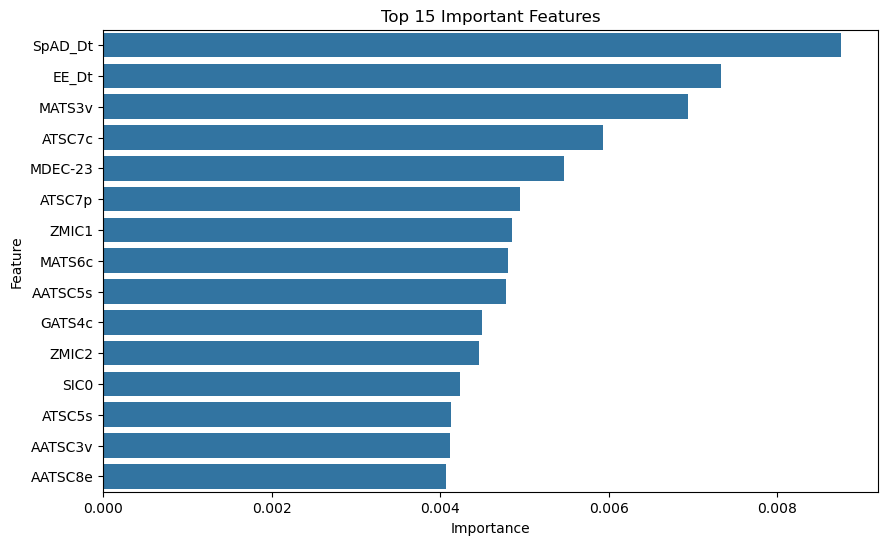

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15)
)
plt.title("Top 15 Important Features")
plt.show()

In [18]:
top_n = 90

top_features = feature_importance_df['Feature'].head(top_n)

X_selected = X[top_features]

print("Selected feature shape:", X_selected.shape)

Selected feature shape: (171, 90)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (136, 90)
Test shape: (35, 90)


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Cross-validation on training data
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.67857143 0.62962963 0.55555556 0.77777778 0.74074074]
Mean CV accuracy: 0.6764550264550264


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train on full training set
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.6571428571428571

Confusion Matrix:
 [[22  2]
 [10  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.92      0.79        24
           1       0.33      0.09      0.14        11

    accuracy                           0.66        35
   macro avg       0.51      0.50      0.46        35
weighted avg       0.58      0.66      0.58        35



In [22]:
print(pd.Series(y_train).value_counts())

0    91
1    45
Name: count, dtype: int64


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

In [24]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Mean CV F1:", cv_scores.mean())

Mean CV F1: 0.4011965811965812


In [25]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.83      0.75        24
           1       0.33      0.18      0.24        11

    accuracy                           0.63        35
   macro avg       0.51      0.51      0.50        35
weighted avg       0.58      0.63      0.59        35



In [26]:
import numpy as np
from sklearn.metrics import classification_report

# 1. FIT the pipeline first (This is the missing step!)
# Replace X_train and y_train with your actual training variable names
pipeline.fit(X_train, y_train)

# 2. Get probabilities for the positive class (class 1)
y_probs = pipeline.predict_proba(X_test)[:, 1]

# 3. Apply the custom threshold (0.3)
# This converts probabilities > 0.3 to 1, and others to 0
threshold = 0.3
y_pred_adjusted = (y_probs > threshold).astype(int)

# 4. Evaluate the results
print(f"Classification Report (Threshold: {threshold}):")
print(classification_report(y_test, y_pred_adjusted))

Classification Report (Threshold: 0.3):
              precision    recall  f1-score   support

           0       0.93      0.58      0.72        24
           1       0.50      0.91      0.65        11

    accuracy                           0.69        35
   macro avg       0.72      0.75      0.68        35
weighted avg       0.80      0.69      0.70        35

